In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# Paramètres 

EPS = 1e-4  # éviter t = 0 (singularité)
# Paramètres du rough Heston
H = 0.1
lam = 0.3
nu = 0.3
rho = -0.7

V0 = 0.02
theta = 0.02
S0 = 1.0

T = 1.0
N = 5000
dt = T / N
t_grid = np.linspace(0.0, T, N + 1)

## Convergence du noyau $K^n$ vers $K$



In [2]:
# Fonction de noyau K(t) pour le rough Heston
def K_exact(t, H):
    return t**(H - 0.5) / gamma(H + 0.5)

In [3]:
def mu_constant(H):
    return 1.0 / (gamma(H + 0.5) * gamma(0.5 - H))

In [4]:
# Fonction pour calculer la valeur optimale pi_n
def optimal_pi_n(n, H, T):
    factor = (np.sqrt(10) * (1 - 2*H) / (5 - 2*H))**(2/5)
    return (n**(-1/5)) * (T**(-1)) * factor

In [5]:
def eta_grid(n, pi_n):
    return np.arange(n + 1) * pi_n

In [6]:
# Fonction pour calculer les coefficients c
def compute_c(eta_left, eta_right, H):
    C = mu_constant(H)
    power = 0.5 - H
    return C / power * (eta_right**power - eta_left**power)

In [7]:
# Fonction pour calculer gamma
def compute_gamma(eta_left, eta_right, H):
    C = mu_constant(H)

    num_power = 1.5 - H
    numerator = C / num_power * (
        eta_right**num_power - eta_left**num_power
    )

    denominator = compute_c(eta_left, eta_right, H)

    return numerator / denominator

In [8]:
# Fonction pour construire les coefficients c_i et gamma_i
def build_coefficients(n, H, T):
    pi_n = optimal_pi_n(n, H, T)
    eta = eta_grid(n, pi_n)

    c = np.zeros(n)
    gamma_vals = np.zeros(n)

    for i in range(1, n + 1):
        eta_l = eta[i-1]
        eta_r = eta[i]

        c[i-1] = compute_c(eta_l, eta_r, H)
        gamma_vals[i-1] = compute_gamma(eta_l, eta_r, H)

    return pi_n, c, gamma_vals

In [9]:
# Fonction pour calculer l'approximation K_approx(t)
def K_approx(t, c, gamma_vals):
    expo = np.exp(-np.outer(gamma_vals, t))
    return np.sum(c[:, None] * expo, axis=0)

In [10]:
t = np.linspace(EPS, T, 4000)
K = K_exact(t, H)

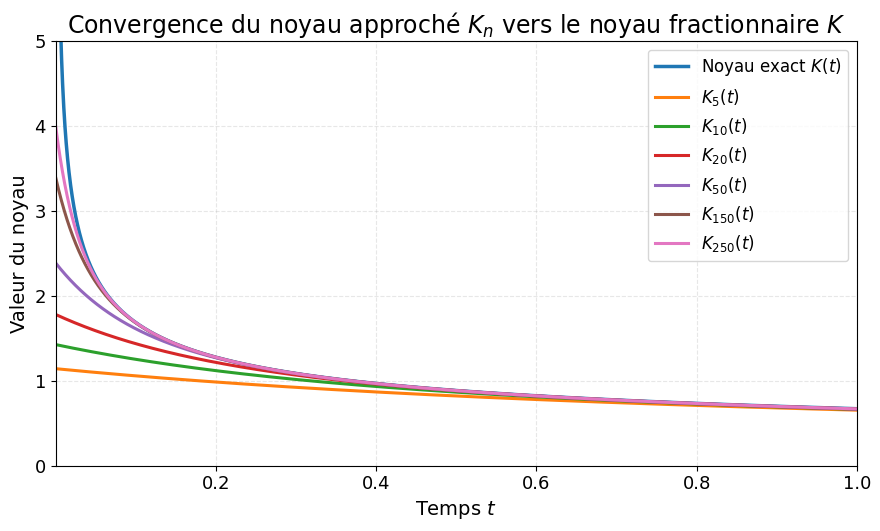

In [11]:
#Affichage de la convergence du noyau approché K_n vers le noyau exact K
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

n_values = [5, 10, 20, 50, 150,250]

fig, ax = plt.subplots()

# Noyau exact
ax.plot(t, K, label=r"Noyau exact $K(t)$", linewidth=2.5)

# Approximations
for n in n_values:
    pi_n, c, gamma_vals = build_coefficients(n, H, T)
    K_n = K_approx(t, c, gamma_vals)
    ax.plot(t, K_n, label=rf"$K_{{{n}}}(t)$")


ax.set_title(r"Convergence du noyau approché $K_n$ vers le noyau fractionnaire $K$")
ax.set_xlabel(r"Temps $t$")
ax.set_ylabel(r"Valeur du noyau")

ax.legend(frameon=True)
ax.grid(True)


ax.set_xlim(t.min(), t.max())
ax.set_ylim(0, 5)

plt.tight_layout()

plt.savefig("convergence_kn.png", dpi=300)

plt.show()

In [12]:
# Fonction pour calculer l'erreur L2 entre K et K_n
def L2_error(K, K_n, t):
    return np.sqrt(np.trapezoid((K - K_n)**2, t))

In [13]:
# Calcul de l'erreur L2 pour chaque n
n_values = [5, 10, 20, 50, 150, 250]
errors = []

for n in n_values:
    pi_n, c, gamma_vals = build_coefficients(n, H, T)
    K_n = K_approx(t, c, gamma_vals)

    err = L2_error(K, K_n, t)
    errors.append(err)

    print(f"n = {n}, erreur L2 = {err:.6e}")

n = 5, erreur L2 = 7.882586e-01
n = 10, erreur L2 = 7.239136e-01
n = 20, erreur L2 = 6.616798e-01
n = 50, erreur L2 = 5.822748e-01
n = 150, erreur L2 = 4.908862e-01
n = 250, erreur L2 = 4.497029e-01


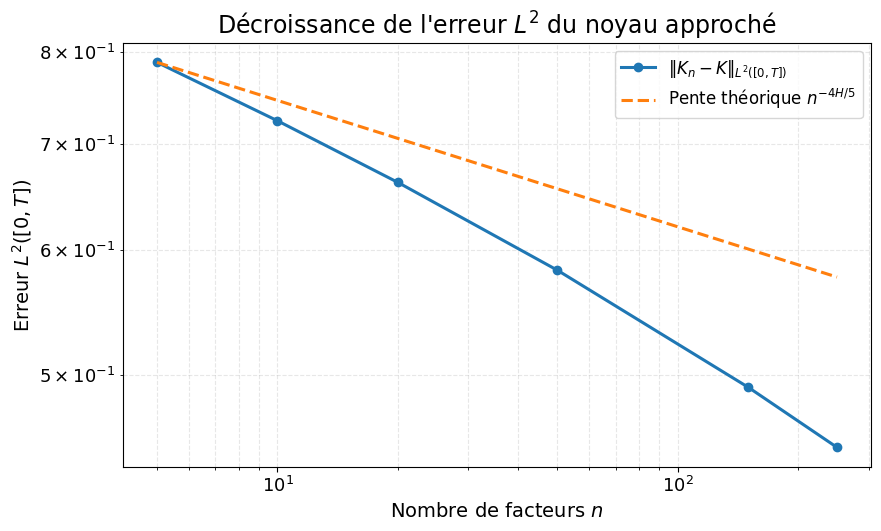

In [14]:
# Affichage de la convergence de l'erreur L2 en fonction de n
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

fig, ax = plt.subplots()

# Erreur numérique
ax.loglog(n_values, errors, marker='o', label=r"$\|K_n - K\|_{L^2([0,T])}$")

# Pente théorique ~ n^{-4H/5}
ref = [errors[0] * (n_values[0]/n)**(4*H/5) for n in n_values]
ax.loglog(n_values, ref, '--', label=rf"Pente théorique $n^{{-4H/5}}$")

# Mise en forme
ax.set_title(r"Décroissance de l'erreur $L^2$ du noyau approché")
ax.set_xlabel(r"Nombre de facteurs $n$")
ax.set_ylabel(r"Erreur $L^2([0,T])$")

ax.legend(frameon=True)
ax.grid(True, which="both")

plt.tight_layout()

# Sauvegarde HD
plt.savefig("erreur_convergence_kn.png", dpi=300)

plt.show()

In [15]:
def compute_gn_constant_theta(t_grid, V0, theta, c, gamma_n):
    g_n = np.full_like(t_grid, fill_value=V0, dtype=float)

    for k, t in enumerate(t_grid):
        g_n[k] += theta * np.sum(c * (1.0 - np.exp(-gamma_n * t)) / gamma_n)

    return g_n

## Schéma implicite pour ^n$

Le schéma d'Euler **implicite** traite le terme de retour à la moyenne \gamma_i^n V^{n,i}$ au pas de temps suivant, ce qui améliore la stabilité numérique :

24V^{n,i}_{k+1} = \frac{V^{n,i}_k + \left(-\lambda V^n_k\right)\Delta t + \nu\sqrt{V^n_k}\,\Delta B_k}{1 + \gamma_i^n \Delta t}24

Chaque facteur reste **analytiquement soluble** (pas de système linéaire). Les termes de couplage et de diffusion restent explicites.


## Simulation des $V^n$ 



In [16]:
# Fonction pour simuler les Vn(t) — schéma d'Euler implicite sur les facteurs
def simulate_Vn_factors(t_grid, V0, theta, lam, nu, H, n_factors, dB=None, seed=None):
    """
    Schéma d'Euler implicite pour chaque facteur V^{n,i}.

    L'EDS de chaque facteur est :
        dV^{n,i} = (-gamma_i * V^{n,i} - lambda * V^n) dt + nu * sqrt(V^n) dB

    En traitant le terme -gamma_i * V^{n,i}_{k+1} de façon implicite :
        V^{n,i}_{k+1} = (V^{n,i}_k + (-lambda * V^n_k) * dt + nu * sqrt(V^n_k) * dB_k)
                        / (1 + gamma_i * dt)

    Le terme de couplage -lambda * V^n_k et la diffusion restent explicites.
    Chaque facteur se résout donc analytiquement, sans système linéaire.
    """
    if seed is not None:
        np.random.seed(seed)

    N  = len(t_grid) - 1
    dt = t_grid[1] - t_grid[0]

    eta, c, gamma_n = build_coefficients(n_factors, H, t_grid[-1])
    g_n = compute_gn_constant_theta(t_grid, V0, theta, c, gamma_n)

    if dB is None:
        dB = np.sqrt(dt) * np.random.randn(N)

    # Dénominateurs implicites : (1 + gamma_i * dt), précalculés
    implicit_denom = 1.0 + gamma_n * dt   # shape (n_factors,)

    factors = np.zeros((n_factors, N + 1), dtype=float)
    Vn      = np.zeros(N + 1, dtype=float)

    Vn[0] = V0

    for k in range(N):
        V_current = g_n[k] + np.sum(c * factors[:, k])
        V_current = max(V_current, 0.0)
        Vn[k] = V_current

        sqrt_V = np.sqrt(V_current)

        # Numérateur commun à tous les facteurs
        common = -lam * V_current * dt + nu * sqrt_V * dB[k]

        # Mise à jour implicite vectorisée
        factors[:, k + 1] = (factors[:, k] + common) / implicit_denom

    Vn[-1] = max(g_n[-1] + np.sum(c * factors[:, -1]), 0.0)

    return Vn, factors, g_n, c, gamma_n, dB


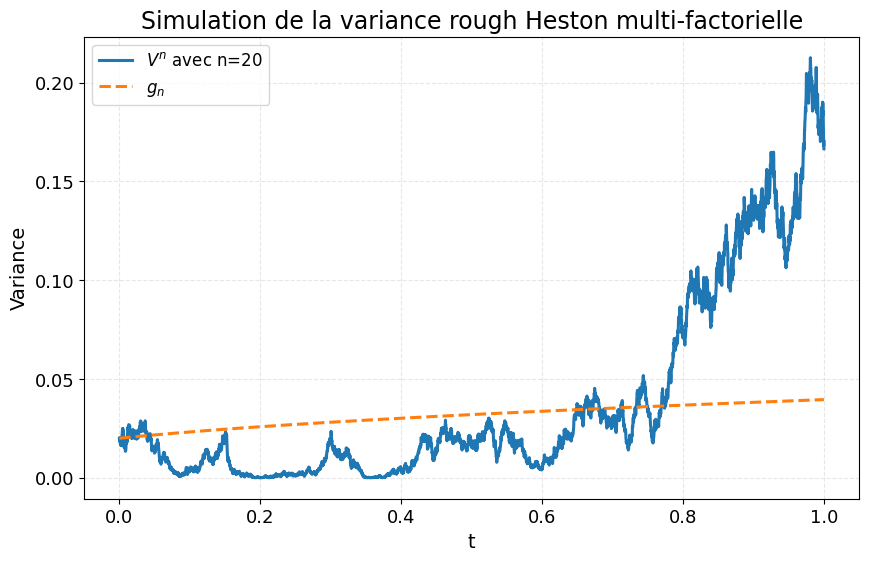

In [17]:
# Simulation avec n_factors = 20
n_factors = 20

Vn, factors, g_n, c, gamma_n, dB = simulate_Vn_factors(
    t_grid=t_grid,
    V0=V0,
    theta=theta,
    lam=lam,
    nu=nu,
    H=H,
    n_factors=n_factors,
    seed=123
)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, Vn, label=fr"$V^n$ avec n={n_factors}")
plt.plot(t_grid, g_n, "--", label=fr"$g_n$")
plt.xlabel("t")
plt.ylabel("Variance")
plt.title("Simulation de la variance rough Heston multi-factorielle")
plt.legend()
plt.grid(True)
plt.show()

## Comparaison des trajectoires de $V^n$ pour différentes valeurs de $n$


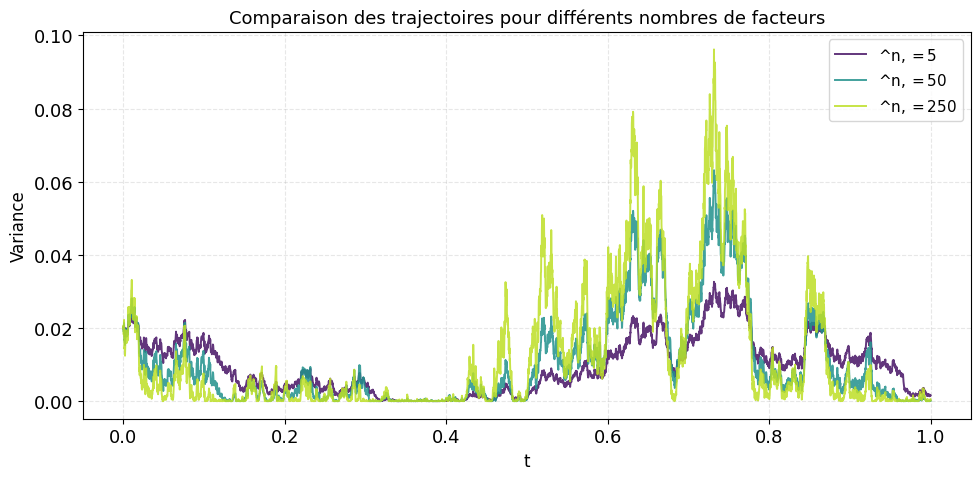

In [18]:
def plot_Vn_comparison(t_grid, V0, theta, lam, nu, H, rho,
                       n_values=[5, 50, 250], seed=42):
    """
    Trace les trajectoires du processus de variance V^n (schéma implicite)
    pour plusieurs valeurs du nombre de facteurs n, sur le même graphique.
    Style identique à la Figure 3 du rapport (couleurs viridis, même bruit).

    Paramètres
    ----------
    t_grid  : grille temporelle
    V0, theta, lam, nu, H, rho : paramètres du rough Heston
    n_values : liste des nombres de facteurs à comparer
    seed    : graine aléatoire (même bruit pour toutes les courbes)
    """
    N  = len(t_grid) - 1
    dt = t_grid[1] - t_grid[0]

    # Même réalisation brownienne pour toutes les valeurs de n
    rng = np.random.default_rng(seed)
    dB  = np.sqrt(dt) * rng.standard_normal(N)

    # Couleurs viridis bien espacées (bleu -> orange -> vert)
    colors = [plt.cm.viridis(x) for x in [0.05, 0.5, 0.9]]

    fig, ax = plt.subplots(figsize=(10, 5))

    for color, n in zip(colors, n_values):
        Vn, *_ = simulate_Vn_factors(
            t_grid=t_grid, V0=V0, theta=theta,
            lam=lam, nu=nu, H=H,
            n_factors=n, dB=dB.copy()
        )
        ax.plot(t_grid, Vn, color=color, alpha=0.85, linewidth=1.4,
                label=fr'^n$, ={n}$')

    ax.set_xlabel(r't', fontsize=12)
    ax.set_ylabel(r'Variance', fontsize=12)
    ax.set_title(
        r'Comparaison des trajectoires pour différents nombres de facteurs',
        fontsize=13
    )
    ax.legend(fontsize=11, frameon=True)
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparaison_Vn_n_values.png', dpi=200)
    plt.show()


# ── Appel de la fonction ────────────────────────────────────────────────
plot_Vn_comparison(
    t_grid=t_grid,
    V0=V0, theta=theta, lam=lam, nu=nu, H=H, rho=rho,
    n_values=[5, 50, 250],
    seed=42
)


## Simulation des $S^n$ 



In [ ]:
# Fonction pour simuler les Sn à partir des Vn
def simulate_Sn_from_Vn(S0, Vn, rho, dt, dB, seed=None):
    if seed is not None:
        np.random.seed(seed)

    N = len(Vn) - 1
    dB_perp = np.sqrt(dt) * np.random.randn(N)
    dW = rho * dB + np.sqrt(1.0 - rho**2) * dB_perp

    Sn = np.zeros(N + 1, dtype=float)
    Sn[0] = S0

    for k in range(N):
        V_current = max(Vn[k], 0.0)
        Sn[k + 1] = Sn[k] + Sn[k] * np.sqrt(V_current) * dW[k]

    return Sn

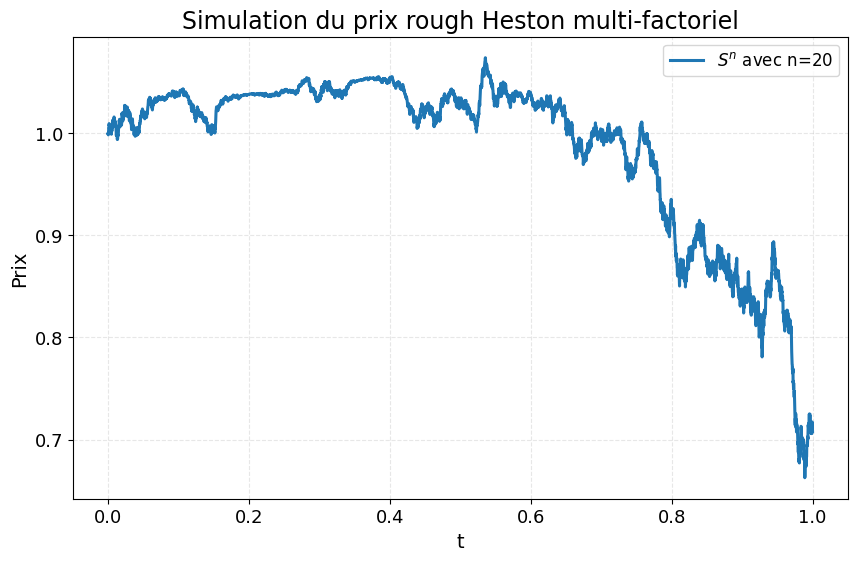

In [ ]:
# Simulation du prix Sn à partir de Vn
Sn = simulate_Sn_from_Vn(
    S0=S0,
    Vn=Vn,
    rho=rho,
    dt=dt,
    dB=dB,
    seed=456
)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, Sn, label=fr"$S^n$ avec n={n_factors}")
plt.xlabel("t")
plt.ylabel("Prix")
plt.title("Simulation du prix rough Heston multi-factoriel")
plt.legend()
plt.grid(True)
plt.show()

## Convergence de $V^n$ — approche Monte Carlo



In [25]:
# ── Paramètres Monte Carlo ──────────────────────────────────────────────
M          = 500          # nombre de trajectoires
factor_list = [5, 10, 20, 50, 100, 200]  # valeurs de n à tester
n_ref      = 500          # référence (grand n)


In [26]:
# ── Simulation Monte Carlo pour chaque n ────────────────────────────────
# Pour chaque n on accumule E[V^n_t] et E[(V^n_t)^2] sur M trajectoires.

def mc_stats_Vn(n_factors, M, t_grid, V0, theta, lam, nu, H, seed=42):
    """Retourne mean[V^n] et std[V^n] estimés par Monte Carlo."""
    rng = np.random.default_rng(seed)
    N   = len(t_grid) - 1
    dt  = t_grid[1] - t_grid[0]
    acc1 = np.zeros(N + 1)   # somme des trajectoires
    acc2 = np.zeros(N + 1)   # somme des carrés
    for _ in range(M):
        dB = np.sqrt(dt) * rng.standard_normal(N)
        Vn, *_ = simulate_Vn_factors(
            t_grid=t_grid, V0=V0, theta=theta,
            lam=lam, nu=nu, H=H,
            n_factors=n_factors, dB=dB
        )
        acc1 += Vn
        acc2 += Vn**2
    mean = acc1 / M
    std  = np.sqrt(np.maximum(acc2 / M - mean**2, 0.0))
    return mean, std

print('Simulation Monte Carlo en cours...')
mc_mean = {}
mc_std  = {}
for n in factor_list + [n_ref]:
    mc_mean[n], mc_std[n] = mc_stats_Vn(
        n, M, t_grid, V0, theta, lam, nu, H, seed=2026
    )
    print(f'  n={n:4d}  E[V_T] = {mc_mean[n][-1]:.6f}')
print('Terminé.')


Simulation Monte Carlo en cours...
  n=   5  E[V_T] = 0.029887
  n=  10  E[V_T] = 0.030458
  n=  20  E[V_T] = 0.030702
  n=  50  E[V_T] = 0.030843
  n= 100  E[V_T] = 0.030665
  n= 200  E[V_T] = 0.030085
  n= 500  E[V_T] = 0.029631
Terminé.


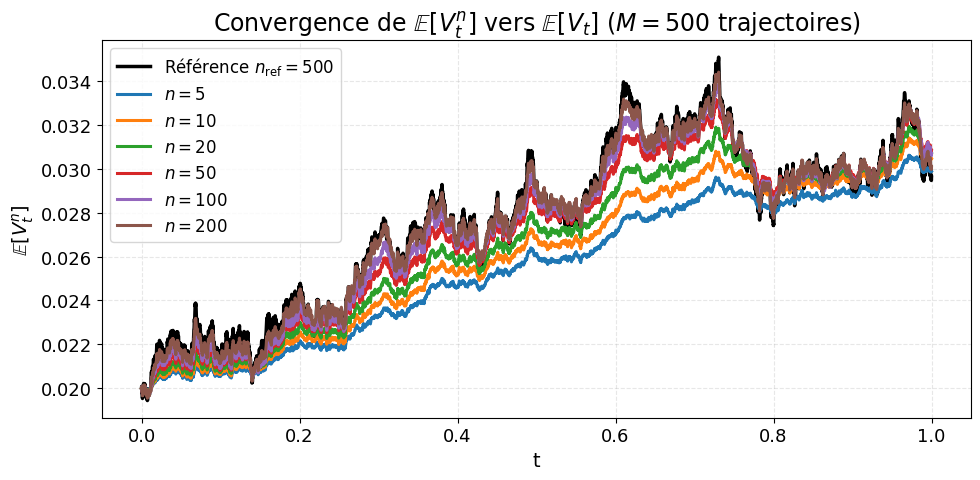

In [27]:
# ── Figure 1 : espérances E[V^n_t] pour différents n ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_grid, mc_mean[n_ref], 'k-', linewidth=2.5,
        label=fr'Référence $n_{{\mathrm{{ref}}}}={n_ref}$')
for n in factor_list:
    ax.plot(t_grid, mc_mean[n], label=fr'$n={n}$')

ax.set_xlabel('t')
ax.set_ylabel(r'$\mathbb{E}[V^n_t]$')
ax.set_title(
    fr'Convergence de $\mathbb{{E}}[V^n_t]$ vers $\mathbb{{E}}[V_t]$ '
    fr'($M={M}$ trajectoires)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('convergence_mean_Vn.png', dpi=150)
plt.show()


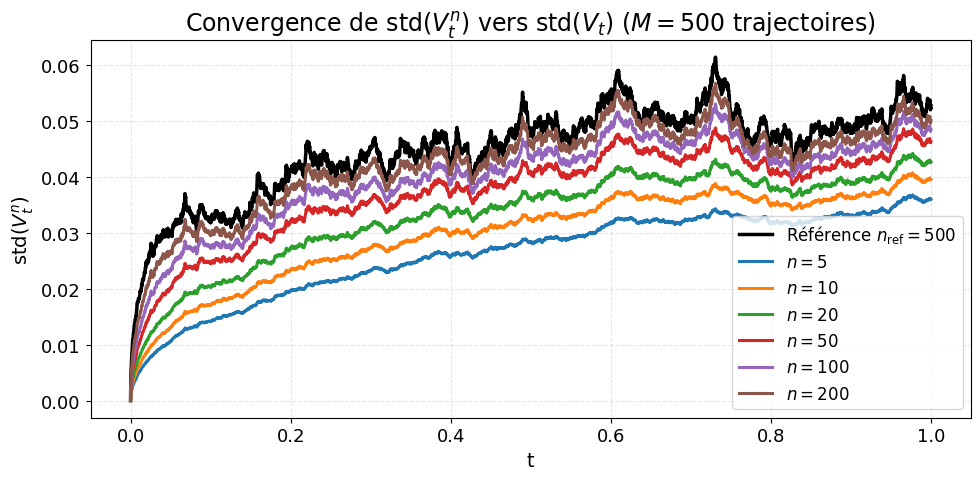

In [28]:
# ── Figure 2 : écarts-types std[V^n_t] pour différents n ───────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_grid, mc_std[n_ref], 'k-', linewidth=2.5,
        label=fr'Référence $n_{{\mathrm{{ref}}}}={n_ref}$')
for n in factor_list:
    ax.plot(t_grid, mc_std[n], label=fr'$n={n}$')

ax.set_xlabel('t')
ax.set_ylabel(r'$\mathrm{std}(V^n_t)$')
ax.set_title(
    fr'Convergence de $\mathrm{{std}}(V^n_t)$ vers $\mathrm{{std}}(V_t)$ '
    fr'($M={M}$ trajectoires)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('convergence_std_Vn.png', dpi=150)
plt.show()


In [29]:
# ── Erreurs L2(0,T) de E[V^n] par rapport à la référence ───────────────
l2_errors_mean = []
l2_errors_std  = []

print(f'{'n':>6}  {'Err L2 E[V^n]':>18}  {'Err L2 std[V^n]':>18}')
print('-' * 48)
for n in factor_list:
    e_mean = np.sqrt(np.trapezoid((mc_mean[n] - mc_mean[n_ref])**2, t_grid))
    e_std  = np.sqrt(np.trapezoid((mc_std[n]  - mc_std[n_ref])**2,  t_grid))
    l2_errors_mean.append(e_mean)
    l2_errors_std.append(e_std)
    print(f'{n:>6}  {e_mean:>18.6e}  {e_std:>18.6e}')


     n       Err L2 E[V^n]     Err L2 std[V^n]
------------------------------------------------
     5        2.479178e-03        1.903413e-02
    10        1.904057e-03        1.541205e-02
    20        1.394965e-03        1.201170e-02
    50        8.152671e-04        7.900490e-03
   100        5.174721e-04        5.173011e-03
   200        2.512786e-04        2.681847e-03


## Impacts des paramètres sur $S^n$ et $V^n$ 



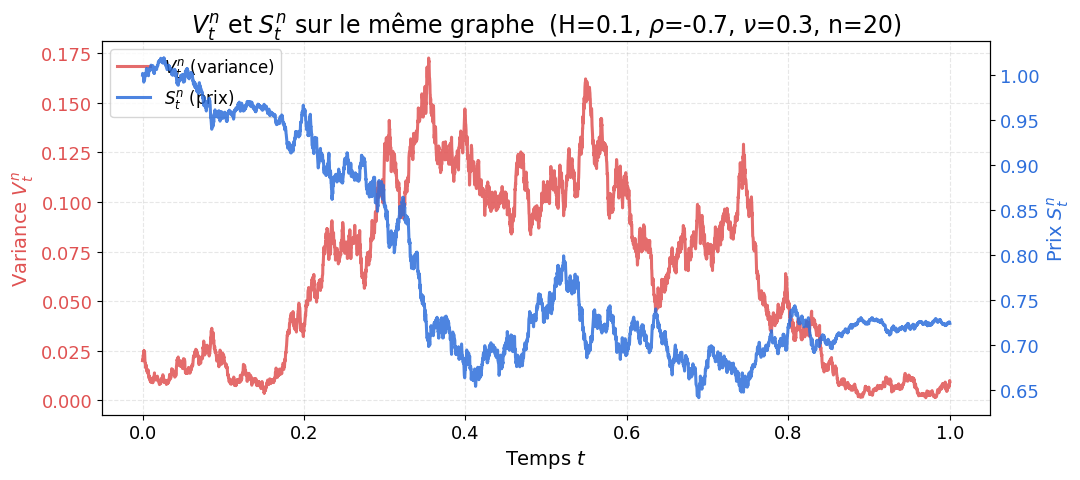

In [21]:
# ══════════════════════════════════════════════════════════════
# Graphique 1 — V^n et S^n sur le même graphe (double axe y)
# ══════════════════════════════════════════════════════════════

SEED_V    = 42
SEED_S    = 7
N_FACTORS = 20

np.random.seed(SEED_V)
dB_ref = np.sqrt(dt) * np.random.randn(N)

Vn_ref, _, _, _, _, _ = simulate_Vn_factors(
    t_grid=t_grid, V0=V0, theta=theta, lam=lam, nu=nu, H=H,
    n_factors=N_FACTORS, dB=dB_ref.copy()
)
Sn_ref = simulate_Sn_from_Vn(
    S0=S0, Vn=Vn_ref, rho=rho, dt=dt, dB=dB_ref, seed=SEED_S
)

fig, ax1 = plt.subplots(figsize=(11, 5))

color_V = '#e05252'
color_S = '#2e6fdb'

ax1.plot(t_grid, Vn_ref, color=color_V, alpha=0.85, label=r'$V^n_t$ (variance)')
ax1.set_xlabel('Temps $t$')
ax1.set_ylabel(r'Variance $V^n_t$', color=color_V)
ax1.tick_params(axis='y', labelcolor=color_V)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t_grid, Sn_ref, color=color_S, alpha=0.85, label=r'$S^n_t$ (prix)')
ax2.set_ylabel(r'Prix $S^n_t$', color=color_S)
ax2.tick_params(axis='y', labelcolor=color_S)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(fr'$V^n_t$ et $S^n_t$ sur le même graphe  (H={H}, $\rho$={rho}, $\nu$={nu}, n={N_FACTORS})')
plt.tight_layout()
plt.show()

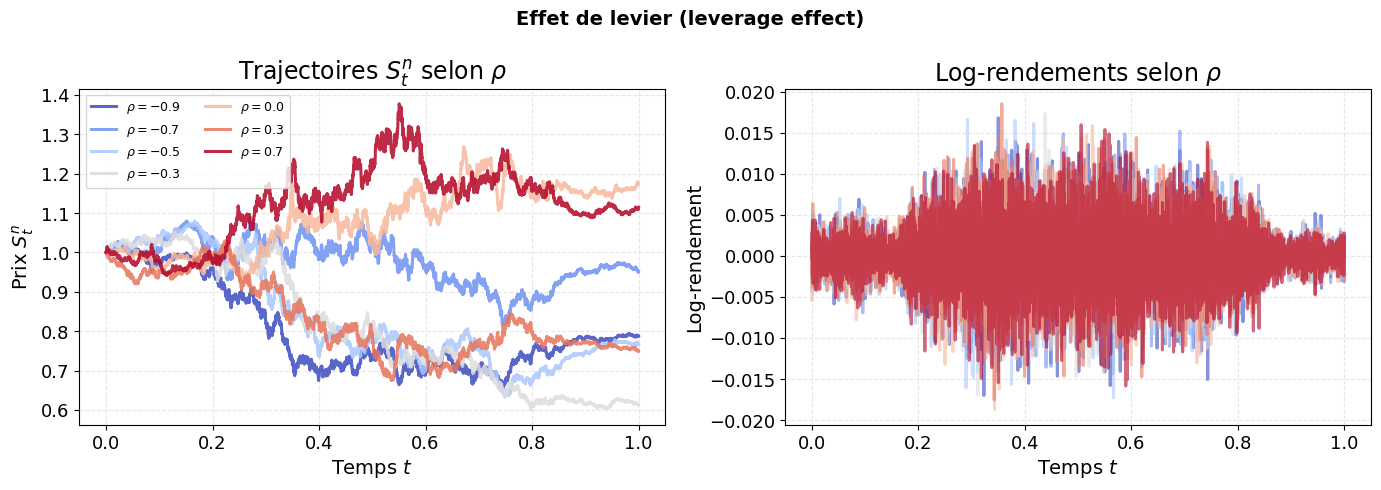

In [22]:
# ══════════════════════════════════════════════════════════════
# Graphique 2 — Effet de levier : impact de rho sur S^n
# ══════════════════════════════════════════════════════════════

rho_values = [-0.9, -0.7, -0.5, -0.3, 0.0, 0.3, 0.7]
cmap_lev   = plt.cm.coolwarm

np.random.seed(SEED_V)
dB_lev = np.sqrt(dt) * np.random.randn(N)
Vn_lev, _, _, _, _, _ = simulate_Vn_factors(
    t_grid=t_grid, V0=V0, theta=theta, lam=lam, nu=nu, H=H,
    n_factors=N_FACTORS, dB=dB_lev.copy()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_sn, ax_ret = axes

for i, rho_val in enumerate(rho_values):
    color   = cmap_lev(i / (len(rho_values) - 1))
    Sn_lev  = simulate_Sn_from_Vn(
        S0=S0, Vn=Vn_lev, rho=rho_val, dt=dt, dB=dB_lev, seed=SEED_S + i
    )
    ax_sn.plot(t_grid, Sn_lev, color=color, label=rf'$\rho={rho_val}$', alpha=0.85)
    log_ret = np.diff(np.log(np.maximum(Sn_lev, 1e-10)))
    ax_ret.plot(t_grid[1:], log_ret, color=color, alpha=0.6)

ax_sn.set_title(r'Trajectoires $S^n_t$ selon $\rho$')
ax_sn.set_xlabel('Temps $t$')
ax_sn.set_ylabel(r'Prix $S^n_t$')
ax_sn.legend(fontsize=9, ncol=2)
ax_sn.grid(True, linestyle='--', alpha=0.3)

ax_ret.set_title(r'Log-rendements selon $\rho$')
ax_ret.set_xlabel('Temps $t$')
ax_ret.set_ylabel('Log-rendement')
ax_ret.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Effet de levier (leverage effect)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

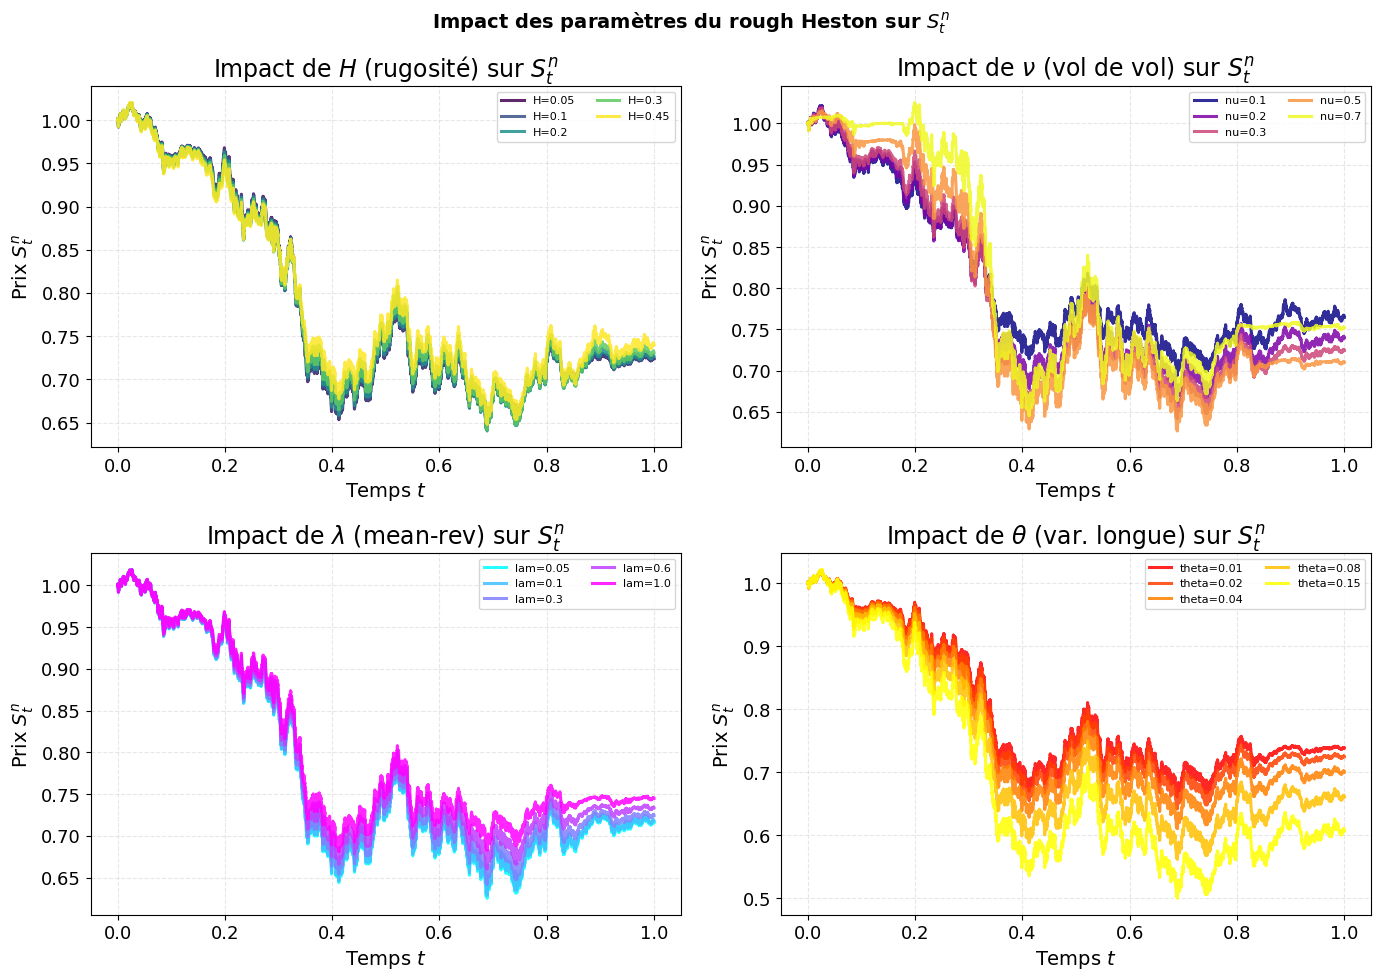

In [23]:
# ══════════════════════════════════════════════════════════════
# Graphique 3 — Impact des paramètres H, nu, lam, theta sur S^n
# ══════════════════════════════════════════════════════════════

base_params = dict(H=H, lam=lam, nu=nu, theta=theta, rho=rho, V0=V0)

param_configs = [
    {'param': 'H',     'values': [0.05, 0.1, 0.2, 0.3, 0.45], 'label': r'$H$ (rugosité)',       'cmap': plt.cm.viridis},
    {'param': 'nu',    'values': [0.1, 0.2, 0.3, 0.5, 0.7],   'label': r'$\nu$ (vol de vol)',   'cmap': plt.cm.plasma},
    {'param': 'lam',   'values': [0.05, 0.1, 0.3, 0.6, 1.0],  'label': r'$\lambda$ (mean-rev)', 'cmap': plt.cm.cool},
    {'param': 'theta', 'values': [0.01, 0.02, 0.04, 0.08, 0.15], 'label': r'$\theta$ (var. longue)', 'cmap': plt.cm.autumn},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cfg in zip(axes.flatten(), param_configs):
    cm    = cfg['cmap']
    vals  = cfg['values']
    pname = cfg['param']

    np.random.seed(SEED_V)
    dB_par = np.sqrt(dt) * np.random.randn(N)

    for j, val in enumerate(vals):
        color  = cm(j / (len(vals) - 1))
        p      = {**base_params, pname: val}
        Vn_par, _, _, _, _, _ = simulate_Vn_factors(
            t_grid=t_grid, V0=p['V0'], theta=p['theta'],
            lam=p['lam'], nu=p['nu'], H=p['H'],
            n_factors=N_FACTORS, dB=dB_par.copy()
        )
        Sn_par = simulate_Sn_from_Vn(
            S0=S0, Vn=Vn_par, rho=p['rho'], dt=dt, dB=dB_par, seed=SEED_S
        )
        ax.plot(t_grid, Sn_par, color=color, alpha=0.85, label=f'{pname}={val}')

    ax.set_title(f'Impact de {cfg["label"]} sur $S^n_t$')
    ax.set_xlabel('Temps $t$')
    ax.set_ylabel(r'Prix $S^n_t$')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle(r'Impact des paramètres du rough Heston sur $S^n_t$', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

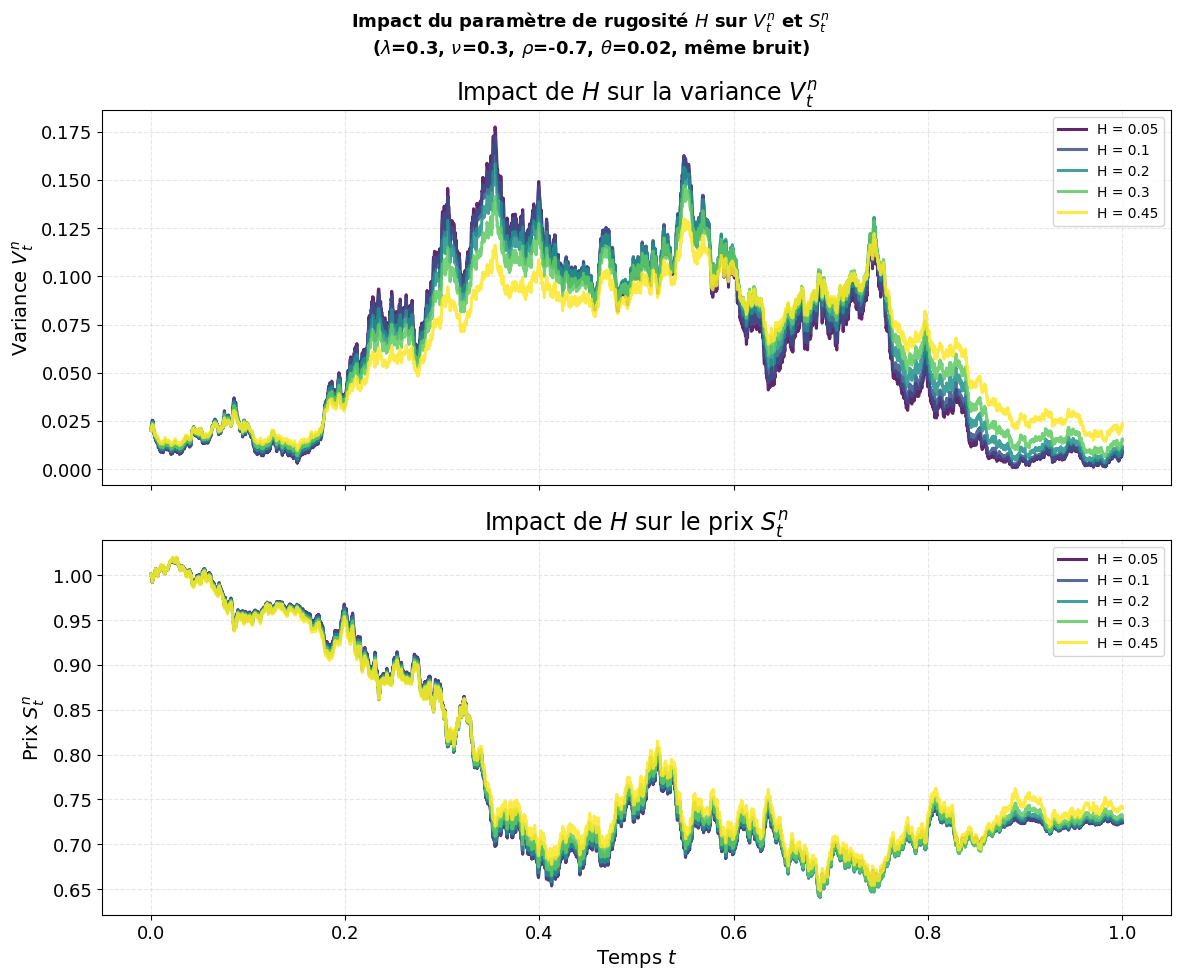

In [ ]:
# ══════════════════════════════════════════════════════════════
# Impact de H sur V^n et S^n
# ══════════════════════════════════════════════════════════════

H_values = [0.05, 0.1, 0.2, 0.3, 0.45]
cmap_H   = plt.cm.viridis

np.random.seed(SEED_V)
dB_H = np.sqrt(dt) * np.random.randn(N)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax_V, ax_S = axes

for j, H_val in enumerate(H_values):
    color = cmap_H(j / (len(H_values) - 1))
    Vn_H, _, _, _, _, _ = simulate_Vn_factors(
        t_grid=t_grid, V0=V0, theta=theta, lam=lam, nu=nu,
        H=H_val, n_factors=N_FACTORS, dB=dB_H.copy()
    )
    Sn_H = simulate_Sn_from_Vn(
        S0=S0, Vn=Vn_H, rho=rho, dt=dt, dB=dB_H, seed=SEED_S
    )
    ax_V.plot(t_grid, Vn_H, color=color, alpha=0.85, label=f'H = {H_val}')
    ax_S.plot(t_grid, Sn_H, color=color, alpha=0.85, label=f'H = {H_val}')

ax_V.set_ylabel(r'Variance $V^n_t$')
ax_V.set_title(r'Impact de $H$ sur la variance $V^n_t$')
ax_V.legend(fontsize=10)
ax_V.grid(True, linestyle='--', alpha=0.3)

ax_S.set_xlabel('Temps $t$')
ax_S.set_ylabel(r'Prix $S^n_t$')
ax_S.set_title(r'Impact de $H$ sur le prix $S^n_t$')
ax_S.legend(fontsize=10)
ax_S.grid(True, linestyle='--', alpha=0.3)

plt.suptitle(
    r'Impact du paramètre de rugosité $H$ sur $V^n_t$ et $S^n_t$'
    f'\n($\\lambda$={lam}, $\\nu$={nu}, $\\rho$={rho}, $\\theta$={theta}, même bruit)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()